In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from typing import Tuple, Dict



In [3]:
# ============================================================
# CONSTANTS
# ============================================================

FREQUENCY = 0.3
Y_OFFSET = 42
MAX_NFEV = 100000
TOLERANCE = 1e-14



In [4]:
# ============================================================
# 1. LOAD DATA
# ============================================================

def load_data(filepath: str) -> Tuple[np.ndarray, np.ndarray]:
    """Load x, y data from CSV file."""
    data = pd.read_csv(filepath)
    x = data["x"].values
    y = data["y"].values
    print(f"Number of points: {len(x)}")
    return x, y


In [5]:

# ============================================================
# 2. DEFINE RESIDUAL FUNCTION (VECTORIZED)
# ============================================================

def residuals(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Calculate residuals for least squares optimization.

    Vectorized for efficiency - avoids repeated trigonometric calculations.
    """
    theta_deg, M, X = params
    theta = np.deg2rad(theta_deg)

    # Pre-compute trig functions once
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    # Recover t from observed points
    t = (x - X) * cos_theta + (y - Y_OFFSET) * sin_theta

    # Transform to perpendicular direction
    v = -(x - X) * sin_theta + (y - Y_OFFSET) * cos_theta

    # Expected oscillation
    v_pred = np.exp(M * t) * np.sin(FREQUENCY * t)

    return v - v_pred



In [6]:

# ============================================================
# 3. PARAMETER BOUNDS
# ============================================================

BOUNDS = (
    [0.000001, -0.049999, 0.000001],      # lower
    [49.999999, 0.049999, 99.999999]       # upper
)

INITIAL_GUESS = [25.0, 0.0, 50.0]

In [7]:
# ============================================================
# 4. OPTIMIZATION FUNCTION
# ============================================================

def optimize_parameters(x: np.ndarray, y: np.ndarray) -> Dict:
    """Perform nonlinear least squares optimization."""
    result = least_squares(
        residuals,
        INITIAL_GUESS,
        args=(x, y),
        bounds=BOUNDS,
        max_nfev=MAX_NFEV,
        xtol=TOLERANCE,
        ftol=TOLERANCE,
        gtol=TOLERANCE
    )

    return {
        'params': result.x,
        'success': result.success,
        'message': result.message,
        'nfev': result.nfev
    }

In [8]:
# ============================================================
# 5. RECOVER t VALUES & RECONSTRUCT CURVE
# ============================================================

def reconstruct_curve(x: np.ndarray, y: np.ndarray, theta_deg: float, M: float, X: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Recover t values and reconstruct the fitted curve."""
    theta = np.deg2rad(theta_deg)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    # Recover t
    t = (x - X) * cos_theta + (y - Y_OFFSET) * sin_theta

    # Reconstruct oscillation
    A = np.exp(M * t) * np.sin(FREQUENCY * t)

    # Reconstruct x, y
    x_pred = t * cos_theta - A * sin_theta + X
    y_pred = Y_OFFSET + t * sin_theta + A * cos_theta

    return t, x_pred, y_pred

In [9]:
# ============================================================
# 6. CALCULATE ERRORS
# ============================================================

def calculate_errors(y_true: np.ndarray, y_pred: np.ndarray, x_true: np.ndarray = None, x_pred: np.ndarray = None) -> Dict:
    """Calculate L1 and other error metrics."""
    if x_true is not None and x_pred is not None:
        x_error = np.abs(x_true - x_pred)
        y_error = np.abs(y_true - y_pred)
        total_error = np.sum(x_error + y_error)
        mean_error = np.mean(x_error + y_error)
    else:
        total_error = np.sum(np.abs(y_true - y_pred))
        mean_error = np.mean(np.abs(y_true - y_pred))

    return {
        'total_l1': total_error,
        'mean_l1': mean_error,
        'max_error': np.max(np.abs(y_true - y_pred)),
        'rmse': np.sqrt(np.mean((y_true - y_pred) ** 2))
    }

In [10]:
# ============================================================
# 7. PLOTTING FUNCTION
# ============================================================

def plot_results(x: np.ndarray, y: np.ndarray, x_pred: np.ndarray, y_pred: np.ndarray, t: np.ndarray):
    """Plot observed data and fitted curve."""
    plt.figure(figsize=(12, 8))

    # Sort by t for smooth plotting
    order = np.argsort(t)

    plt.scatter(x, y, s=8, alpha=0.7, label="Given data", color='blue')
    plt.plot(x_pred[order], y_pred[order], linewidth=2.5, label="Fitted curve", color='red')

    plt.xlabel("x", fontsize=12)
    plt.ylabel("y", fontsize=12)
    plt.title("Curve Parameter Estimation", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Number of points: 1500

Optimizing parameters...

OPTIMIZATION RESULTS
Converged: True
Message: `xtol` termination condition is satisfied.
Function evaluations: 9

Estimated Parameters
--------------------------------------------------
Theta = 29.9999729322°
M     = 0.0299999969
X     = 54.9999982128

Recovered t range
--------------------------------------------------
Minimum t = 6.049405
Maximum t = 59.995171
Range: 53.945765

Error Metrics
--------------------------------------------------
Total L1 error = 0.0052451382
Mean L1 error  = 0.0000034968
Max error      = 0.0000152551
RMSE           = 0.0000030191


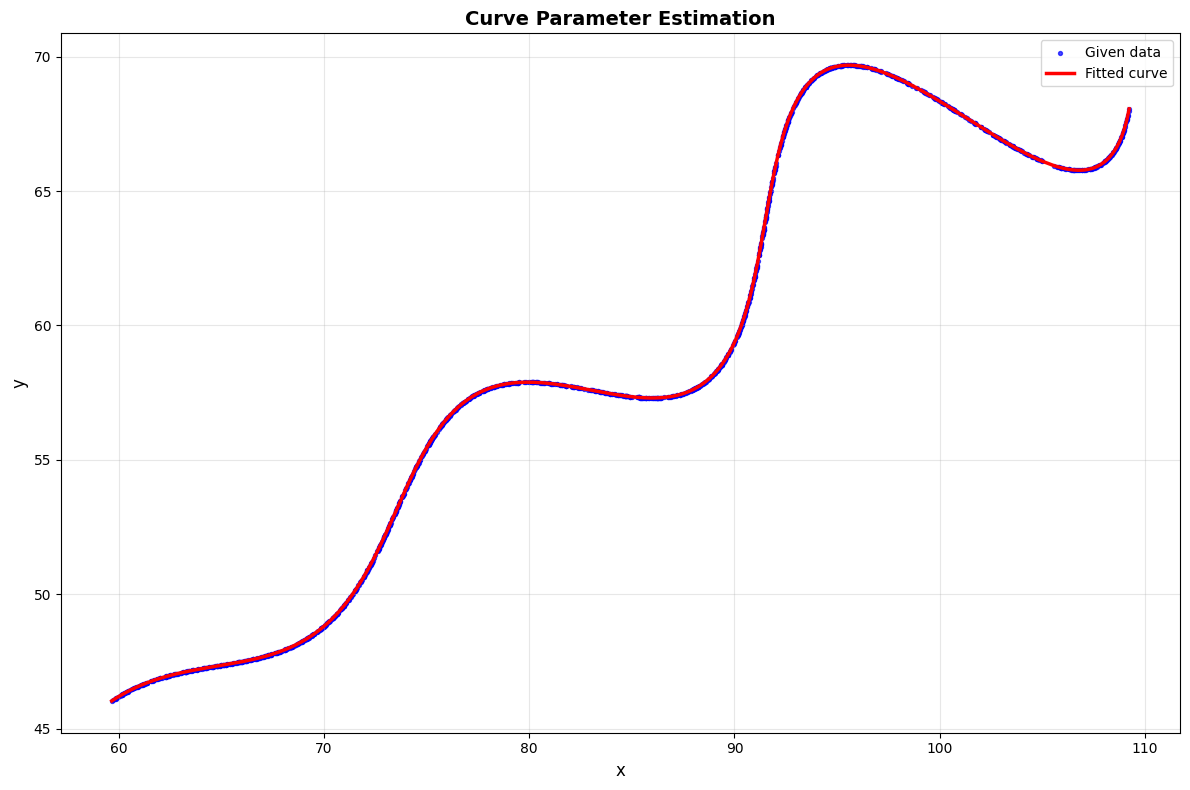

In [11]:
# ============================================================
# 8. MAIN EXECUTION
# ============================================================

def main():
    """Main workflow."""
    # Load data
    x, y = load_data("xy_data.csv")

    # Optimize
    print("\nOptimizing parameters...")
    opt_result = optimize_parameters(x, y)

    theta, M, X = opt_result['params']

    print("\n" + "="*50)
    print("OPTIMIZATION RESULTS")
    print("="*50)
    print(f"Converged: {opt_result['success']}")
    print(f"Message: {opt_result['message']}")
    print(f"Function evaluations: {opt_result['nfev']}")

    print("\nEstimated Parameters")
    print("-" * 50)
    print(f"Theta = {theta:.10f}°")
    print(f"M     = {M:.10f}")
    print(f"X     = {X:.10f}")

    # Reconstruct curve
    t, x_pred, y_pred = reconstruct_curve(x, y, theta, M, X)

    print("\nRecovered t range")
    print("-" * 50)
    print(f"Minimum t = {t.min():.6f}")
    print(f"Maximum t = {t.max():.6f}")
    print(f"Range: {t.max() - t.min():.6f}")

    # Calculate errors
    errors = calculate_errors(y, y_pred, x, x_pred)

    print("\nError Metrics")
    print("-" * 50)
    print(f"Total L1 error = {errors['total_l1']:.10f}")
    print(f"Mean L1 error  = {errors['mean_l1']:.10f}")
    print(f"Max error      = {errors['max_error']:.10f}")
    print(f"RMSE           = {errors['rmse']:.10f}")

    # Plot
    plot_results(x, y, x_pred, y_pred, t)


if __name__ == "__main__":
    main()